In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
!pip install biopython
from Bio import SeqIO

2025-07-30 17:45:38.401704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753897538.784632      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753897538.895181      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
import numpy as np

# Alpha Genome Data
data = np.load("alphagenome_batch_full_up_to_100000.npz")
X_epi = data["X"]
y = data["y"]
X_epi = np.squeeze(X_epi, axis=-1)
X_epi = np.transpose(X_epi, (0, 2, 1))
print(X_epi.shape, y.shape)



(100000, 2, 2048, 1) (100000,)


In [ ]:
center = X_epi.shape[1] // 2
half_len = 1000 // 2
X_epi_t = X_epi[:, center - half_len : center + half_len, :]
print(X_epi_t.shape)  # should now be (#, 1000, 2)


(100000, 1000, 2)


In [ ]:
print(X_epi.shape)

In [ ]:
# Sequence Data
def parse_fasta_with_labels(file_path, num_rows):
    sequences = []
    labels = []
    for i, record in enumerate(SeqIO.parse(file_path, "fasta")):
        if i >= num_rows:
            break
        sequences.append(str(record.seq).upper())
        header = record.description
        label = int(header.split("label=")[-1])
        labels.append(label)
    return sequences, labels

def seq_matrix(seq_list, dim):
    tensor = np.zeros((len(seq_list), dim, 4))
    for i, seq in enumerate(seq_list):
        for j, s in enumerate(seq[:dim]):
            if s == 'A':
                tensor[i, j] = [1, 0, 0, 0]
            elif s == 'T':
                tensor[i, j] = [0, 1, 0, 0]
            elif s == 'C':
                tensor[i, j] = [0, 0, 1, 0]
            elif s == 'G':
                tensor[i, j] = [0, 0, 0, 1]
            else:
                tensor[i, j] = [0, 0, 0, 0]
    return tensor

# Load only the top # sequences from the FASTA file
sequences, labels = parse_fasta_with_labels("final_combined_1to1.fa", num_rows=100000)
print(f"Loaded {len(sequences)} sequences with {sum(labels)} positives and {len(labels)-sum(labels)} negatives")

Loaded 100000 sequences with 49991 positives and 50009 negatives


In [ ]:
import numpy as np

y_npz = y[:100000]
labels_fasta = np.array(labels)

# Check exact match
if np.array_equal(y_npz, labels_fasta):
    print("✅ Labels match exactly.")
else:
    print("Labels do not match.")

✅ Labels match exactly.


In [ ]:
X_seq = seq_matrix(sequences, dim=1000)

In [ ]:
y = np.array(labels)


In [ ]:
from sklearn.model_selection import train_test_split

X_seq_train, X_seq_temp, X_epi_train, X_epi_temp, y_train, y_temp = train_test_split(
    X_seq_filtered,
    X_epi_filtered,
    y_filtered,
    test_size=0.7,
    stratify=y_filtered,
    random_state=5
)

X_seq_val, X_seq_test, X_epi_val, X_epi_test, y_val, y_test = train_test_split(
    X_seq_temp,
    X_epi_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=5
)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization,
    concatenate
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import GlobalMaxPooling1D


# Epigenetic input branch
epi_input = Input(shape=(1000, 2), name="epi_input")
x_epi = Conv1D(64, kernel_size=7, activation="relu", padding="same")(epi_input)# kernel_regularizer=l2(1e-5)
x_epi = BatchNormalization()(x_epi)
x_epi = MaxPooling1D(pool_size=4)(x_epi)
x_epi = Dropout(0.5)(x_epi)
x_epi = Flatten()(x_epi)

# Sequence input branch
seq_input = Input(shape=(1000, 4), name="seq_input")
x_seq = Conv1D(64, kernel_size=7, activation="relu", padding="same")(seq_input) # kernel_regularizer=l2(1e-5)
x_seq = BatchNormalization()(x_seq)
x_seq = MaxPooling1D(pool_size=4)(x_seq)
x_seq = Dropout(0.5)(x_seq)
x_seq = Flatten()(x_seq)

# Merge branches
x = concatenate([x_epi, x_seq])
x = Dense(360, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=[epi_input, seq_input], outputs=output)


I0000 00:00:1753897657.441366      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753897657.442048      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
# Compile the model (if not done already)
from tensorflow.keras.metrics import AUC

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="roc_auc", curve="ROC"), AUC(name="pr_auc", curve="PR")]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_roc_auc',
    factor=0.5,
    patience=10,
    verbose=1,
    min_lr=1e-7
)

early_stop = EarlyStopping(
    monitor="val_roc_auc",
    mode="max",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    {"epi_input": X_epi_train, "seq_input": X_seq_train}, y_train,
    validation_data=(
        {"epi_input": X_epi_val, "seq_input": X_seq_val}, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[reduce_lr, early_stop]
)


Epoch 1/30


I0000 00:00:1753897664.915863     107 service.cc:148] XLA service 0x7d3b74002830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753897664.917031     107 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1753897664.917052     107 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1753897665.457587     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


  16/1620 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5225 - loss: 1.4127 - pr_auc: 0.5549 - roc_auc: 0.4803

I0000 00:00:1753897670.223297     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1620/1620 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.5478 - loss: 0.8115 - pr_auc: 0.5838 - roc_auc: 0.5025 - val_accuracy: 0.5785 - val_loss: 0.6853 - val_pr_auc: 0.5791 - val_roc_auc: 0.5018 - learning_rate: 1.0000e-04
Epoch 2/30
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.5781 - loss: 0.6807 - pr_auc: 0.6159 - roc_auc: 0.5416 - val_accuracy: 0.5787 - val_loss: 0.6705 - val_pr_auc: 0.6800 - val_roc_auc: 0.5893 - learning_rate: 1.0000e-04
Epoch 3/30
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.5792 - loss: 0.6592 - pr_auc: 0.6963 - roc_auc: 0.6095 - val_accuracy: 0.5822 - val_loss: 0.6398 - val_pr_auc: 0.7425 - val_roc_auc: 0.6330 - learning_rate: 1.0000e-04
Epoch 4/30
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.5932 - loss: 0.6273 - pr_auc: 0.7596 - roc_auc: 0.6664 - val_accuracy: 0.5859 - val_loss: 0.6242 - val_pr_auc: 0.7569 - val_roc_auc: 0.6456 - learning_rate: 1.0000e-04
Epoch 5/30
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - a

945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


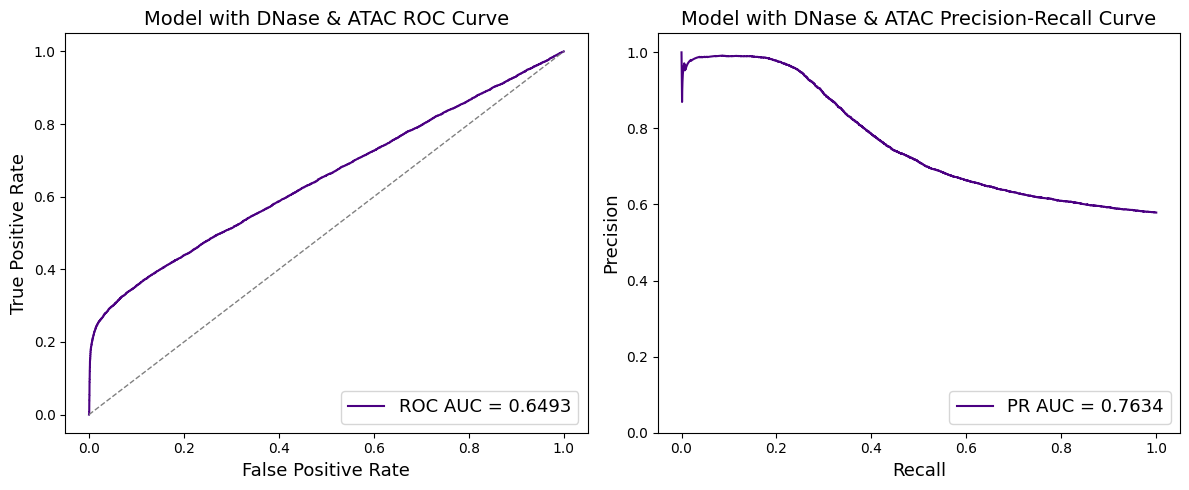

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_probs_1 = model.predict({"epi_input": X_epi_test, "seq_input": X_seq_test}).flatten()  # First model

# --- ROC CURVE ---
fpr_1, tpr_1, _ = roc_curve(y_test, y_pred_probs_1)
roc_auc_1 = auc(fpr_1, tpr_1)


# --- PR CURVE ---
precision_1, recall_1, _ = precision_recall_curve(y_test, y_pred_probs_1)
pr_auc_1 = auc(recall_1, precision_1)


# === PLOT BOTH ROC & PR ===
plt.figure(figsize=(12, 5))

# --- Subplot 1: ROC Curve ---
plt.subplot(1, 2, 1)
plt.plot(fpr_1, tpr_1, color='indigo', lw=1.5, label=f'ROC AUC = {roc_auc_1:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
plt.xlabel('False Positive Rate',fontsize=13)
plt.ylabel('True Positive Rate',fontsize=13)
plt.title('Model with DNase & ATAC ROC Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=13)

# --- Subplot 2: PR Curve ---
plt.subplot(1, 2, 2)
plt.plot(recall_1, precision_1, color='indigo', lw=1.5, label=f'PR AUC = {pr_auc_1:.4f}')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision',fontsize=13)
plt.title('Model with DNase & ATAC Precision-Recall Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=13)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig("this.svg", format='svg')

plt.show()
